# Visualizing HEALPix-geo Zarr Data from EGI DataHub

This notebook demonstrates how to read and visualize HEALPix-geo Zarr data
stored on the EGI DataHub (Reliance space). The dataset `small_hp.zarr` was
produced by the [softwares_RIOMAR](https://github.com/FAIR2Adapt/softwares_RIOMAR)
pipeline, which regrids ocean model output onto a HEALPix grid.

We use:
- [healpix-geo](https://github.com/EOPF-DGGS/healpix-geo) for HEALPix coordinate operations
- [healpix-plot](https://github.com/EOPF-DGGS/healpix-plot) for static map rendering
- [Panel](https://panel.holoviz.org/) for interactive dashboard exploration

**Data location:** `Reliance/FAIR2Adapt/CS2/small_hp.zarr`

In [1]:
import os
from getpass import getpass

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import healpix_geo.nested as hp_nested
import healpix_plot

from egi_datahub_zarr import OnedataZarrStore

## Connect to EGI DataHub

Set your access token via the `DATAHUB_TOKEN` environment variable, or enter it when prompted.

Your token is provider-scoped (Oneprovider only, not Onezone), so we use
`OnedataZarrStore` directly with the known file ID for `small_hp.zarr`.

In [2]:
if not os.environ.get("DATAHUB_TOKEN"):
    os.environ["DATAHUB_TOKEN"] = getpass("Enter your EGI DataHub access token: ")

token = os.environ["DATAHUB_TOKEN"]

# Known file IDs (from Oneprovider REST API)
PROVIDER = "cesnet-oneprovider-01.datahub.egi.eu"
SMALL_HP_ZARR_ID = (
    "00000000005225F567756964236635386230396538623064356331373037316331"
    "386330363334313634663438636863636162233732356634616233366362323664"
    "306662666330633132346337373565666565636865653439"
)

## Open the HEALPix Zarr store

Open `small_hp.zarr` directly using `OnedataZarrStore` with the file ID
obtained from the Oneprovider REST API.

In [ ]:
store = OnedataZarrStore(
    root_file_id=SMALL_HP_ZARR_ID,
    token=token,
    provider=PROVIDER,
    read_only=True,
)

ds = xr.open_zarr(store, consolidated=False, zarr_format=3)

ds = ds.load()
ds

## Explore the dataset structure

Check the dimensions, coordinates, variables, and attributes.

In [4]:
print("Dimensions:", dict(ds.dims))
print("\nCoordinates:")
for name, coord in ds.coords.items():
    print(f"  {name}: {coord.dims} — {coord.dtype}")
print("\nData variables:")
for name, var in ds.data_vars.items():
    print(f"  {name}: {var.dims} — {var.dtype} — {var.attrs.get('long_name', '')}")

Dimensions: {'time_counter': 2208, 's_rho': 40, 'cell_ids': 4544}

Coordinates:
  cell_ids: ('cell_ids',) — int64
  s_rho: ('s_rho',) — float32
  time_counter: ('time_counter',) — datetime64[ns]
  time_instant: ('time_counter',) — datetime64[ns]

Data variables:
  salt: ('time_counter', 's_rho', 'cell_ids') — float64 — salinity
  temp: ('time_counter', 's_rho', 'cell_ids') — float64 — potential temperature
  zeta: ('time_counter', 'cell_ids') — float64 — free-surface


/var/folders/zf/53jxd5nj2j3dmfjqpx41p24c0000gn/T/ipykernel_54372/1936242784.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds.dims))


In [5]:
# Check the cell_ids coordinate attributes (HEALPix metadata)
if "cell_ids" in ds.coords:
    print("cell_ids attributes:", dict(ds["cell_ids"].attrs))
    print(f"cell_ids values (first 10): {ds['cell_ids'].values[:10]}")

cell_ids attributes: {'grid_name': 'healpix', 'level': 13, 'indexing_scheme': 'nested', 'ellipsoid': 'WGS84'}
cell_ids values (first 10): [224374592 224374593 224374594 224374595 224374596 224374597 224374598
 224374599 224374600 224374601]


## Compute cell center coordinates with healpix-geo

Use `healpix_geo.nested` to convert cell IDs to longitude/latitude.
The `level` (depth) and `indexing_scheme` are read from the `cell_ids` attributes.

In [6]:
# Extract HEALPix parameters from cell_ids attributes
cell_ids_coord = ds["cell_ids"]
cell_ids = cell_ids_coord.values.astype(np.uint64)

hp_attrs = dict(cell_ids_coord.attrs)
depth = hp_attrs.get("level", hp_attrs.get("depth"))
ellipsoid = hp_attrs.get("ellipsoid", "WGS84")
print(f"HEALPix depth={depth}, ellipsoid={ellipsoid}, n_cells={len(cell_ids)}")

# Convert cell IDs to lon/lat of cell centers
lon, lat = hp_nested.healpix_to_lonlat(cell_ids, depth=depth, ellipsoid=ellipsoid)

# Add as coordinates to the dataset
ds = ds.assign_coords(longitude=("cell_ids", lon), latitude=("cell_ids", lat))
ds

HEALPix depth=13, ellipsoid=WGS84, n_cells=4544


<xarray.Dataset> Size: 7GB
Dimensions:       (time_counter: 2208, s_rho: 40, cell_ids: 4544)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 18kB 2023-12-01T00:48:10 ... ...
    time_instant  (time_counter) datetime64[ns] 18kB dask.array<chunksize=(2208,), meta=np.ndarray>
  * s_rho         (s_rho) float32 160B -0.9875 -0.9625 ... -0.0375 -0.0125
  * cell_ids      (cell_ids) int64 36kB 224374592 224374593 ... 225780799
    longitude     (cell_ids) float64 36kB 357.6 357.6 357.6 ... 357.3 357.3
    latitude      (cell_ids) float64 36kB 46.95 46.96 46.96 ... 47.38 47.38
Data variables:
    salt          (time_counter, s_rho, cell_ids) float64 3GB dask.array<chunksize=(24, 40, 64), meta=np.ndarray>
    temp          (time_counter, s_rho, cell_ids) float64 3GB dask.array<chunksize=(24, 40, 64), meta=np.ndarray>
    zeta          (time_counter, cell_ids) float64 80MB dask.array<chunksize=(24, 64), meta=np.ndarray>
Attributes: (12/42)
    name:           GAMAR_GLORYS_1h_inst
    description:    Created by xios
    Conventions:    CF-1.6
    title:          GAMAR_GLORYS
    rst_file:       croco_rst.nc
    grd_file:       croco_grd.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL GAMAR MPI TIDES OBC_WEST OBC_NORTH XIOS USE_CALE...

## Select a slice for plotting

Pick the first data variable and select a single time step (and vertical level if present)
to get a 1D array over `cell_ids`.

In [7]:
# Pick the first data variable for visualization
var_name = list(ds.data_vars)[0]
da = ds[var_name]

# Select first time step, and surface level if a vertical dimension exists
extra_dims = [d for d in da.dims if d != "cell_ids"]
sel = {}
for dim in extra_dims:
    sel[dim] = da[dim].values[0]

da_slice = da.sel(sel)
data_values = da_slice.values.astype(np.float64)
print(f"Plotting '{var_name}' with selection: {sel}")
print(f"Data range: {np.nanmin(data_values):.3f} — {np.nanmax(data_values):.3f}")
da_slice

Plotting 'salt' with selection: {'time_counter': np.datetime64('2023-12-01T00:48:10.000000000'), 's_rho': np.float32(-0.9875)}
Data range: -0.232 — 35.182


<xarray.DataArray 'salt' (cell_ids: 4544)> Size: 36kB
dask.array<getitem, shape=(4544,), dtype=float64, chunksize=(64,), chunktype=numpy.ndarray>
Coordinates:
  * cell_ids      (cell_ids) int64 36kB 224374592 224374593 ... 225780799
    longitude     (cell_ids) float64 36kB 357.6 357.6 357.6 ... 357.3 357.3
    latitude      (cell_ids) float64 36kB 46.95 46.96 46.96 ... 47.38 47.38
    s_rho         float32 4B -0.9875
    time_counter  datetime64[ns] 8B 2023-12-01T00:48:10
    time_instant  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    long_name:           salinity
    units:               PSU
    online_operation:    instant
    interval_operation:  1 h
    interval_write:      1 h
    cell_methods:        time: point

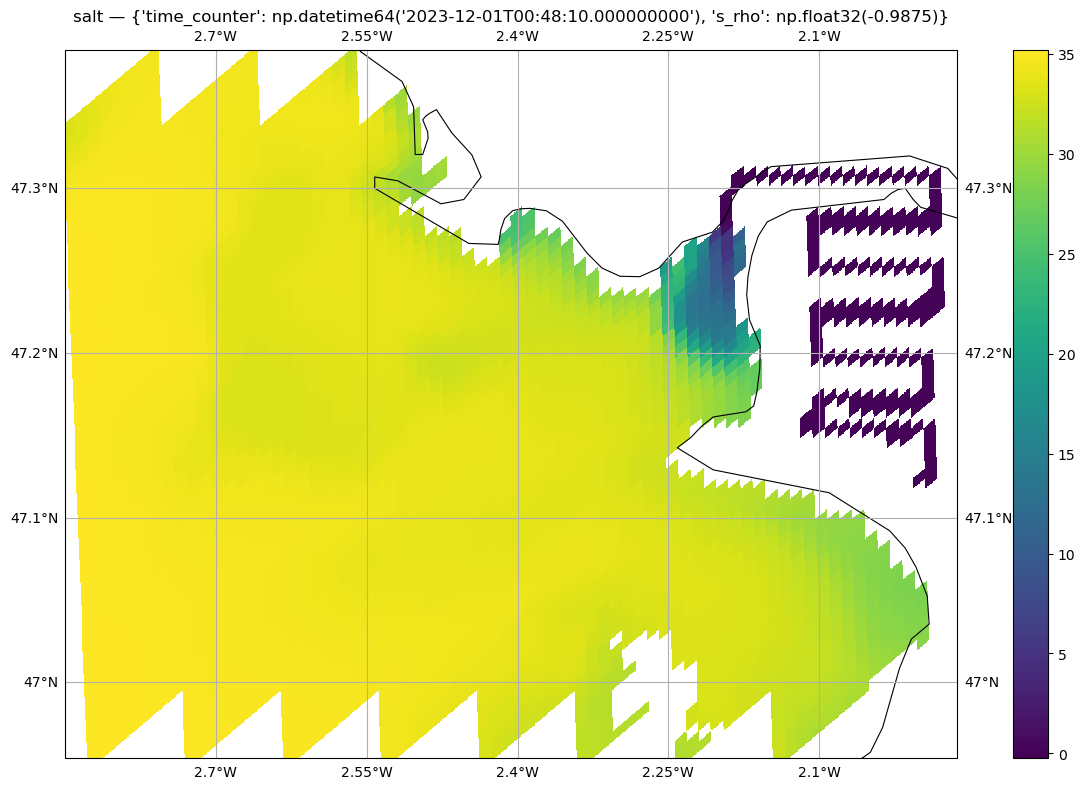

In [8]:
# Static map with healpix-plot (resamples HEALPix cells onto a raster grid)
healpix_grid = healpix_plot.HealpixGrid(
    level=depth, indexing_scheme="nested", ellipsoid=ellipsoid
)

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(12, 8),
)

mappable = healpix_plot.plot(
    cell_ids,
    data_values,
    healpix_grid=healpix_grid,
    sampling_grid={"shape": 1024},
    projection="PlateCarree",
    ax=ax,
    cmap="viridis",
    colorbar=True,
)

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.gridlines(draw_labels=True)
ax.set_title(f"{var_name} — {sel}")
plt.tight_layout()
plt.show()

## Plot all variables (first time step, surface level)

Quick overview of every variable in the dataset.

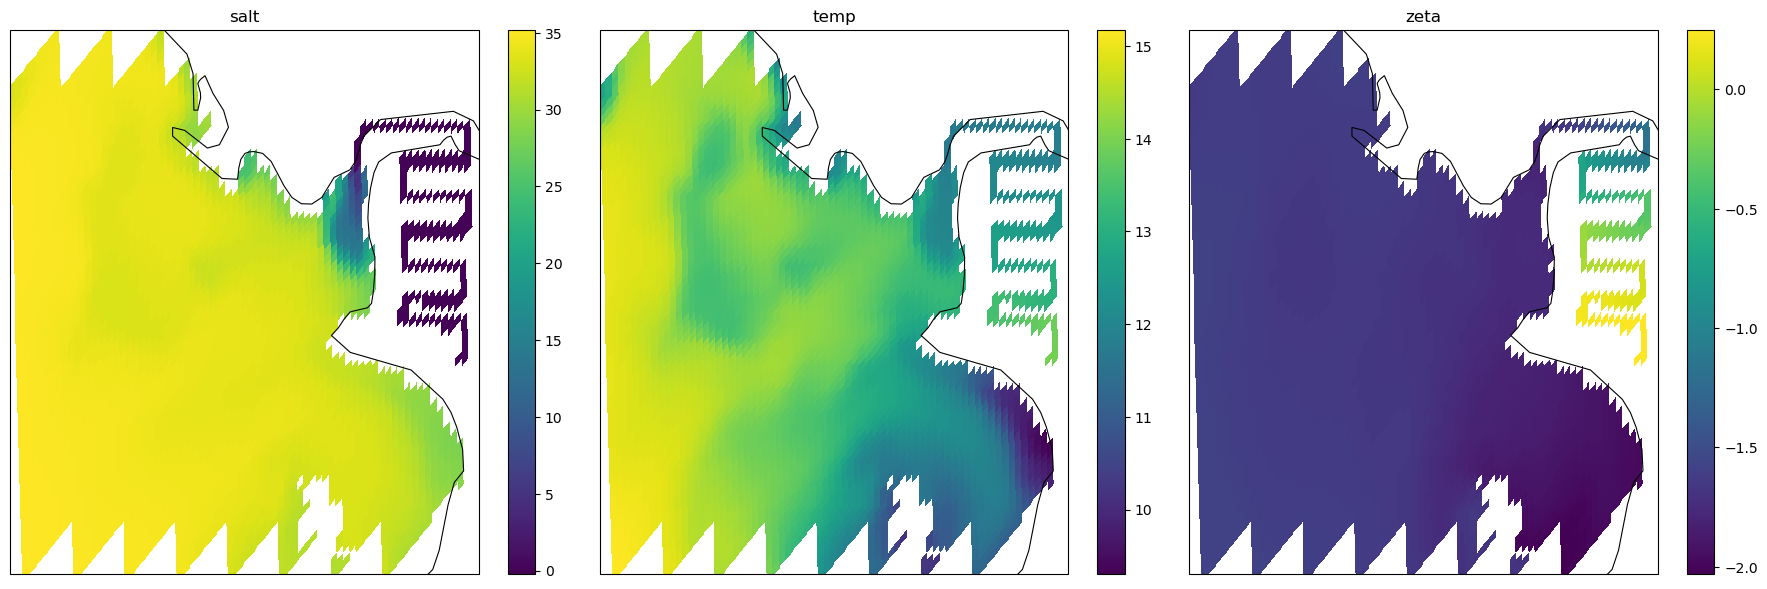

In [9]:
# Plot all data variables (first time step, surface level)
var_names = list(ds.data_vars)
n_vars = len(var_names)
fig, axes = plt.subplots(
    1, n_vars,
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(6 * n_vars, 6),
)
if n_vars == 1:
    axes = [axes]

for ax, vname in zip(axes, var_names):
    da_v = ds[vname]
    # Select first index along all non-cell_ids dimensions
    sel_v = {}
    for dim in da_v.dims:
        if dim != "cell_ids":
            sel_v[dim] = da_v[dim].values[0]
    values = da_v.sel(sel_v).values.astype(np.float64)

    healpix_plot.plot(
        cell_ids,
        values,
        healpix_grid=healpix_grid,
        sampling_grid={"shape": 512},
        projection="PlateCarree",
        ax=ax,
        cmap="viridis",
        colorbar=True,
    )
    ax.coastlines(linewidth=0.8)
    ax.set_title(f"{vname}")

plt.tight_layout()
plt.show()

## Interactive dashboard with Panel

Use [Panel](https://panel.holoviz.org/) widgets to interactively select the variable,
time step, and vertical level, and update the plot dynamically.

Row
    [0] Column
        [0] Markdown(str)
        [1] Select(name='Variable', options=['salt', 'temp', 'zeta'], value='salt')
        [2] DiscreteSlider(formatter='%d', name='time_counter', options={'2023-12-01T00:48:10.0000...}, value=0)
        [3] DiscreteSlider(formatter='%d', name='s_rho', options={'-0.9875': 0, ...}, value=0)
        [4] Select(name='Colormap', options=['viridis', 'plasma', ...], value='viridis')
        [5] IntSlider(end=2048, name='Resolution', start=256, step=256, value=512)
    [1] ParamFunction(function, _pane=Matplotlib, defer_load=False)
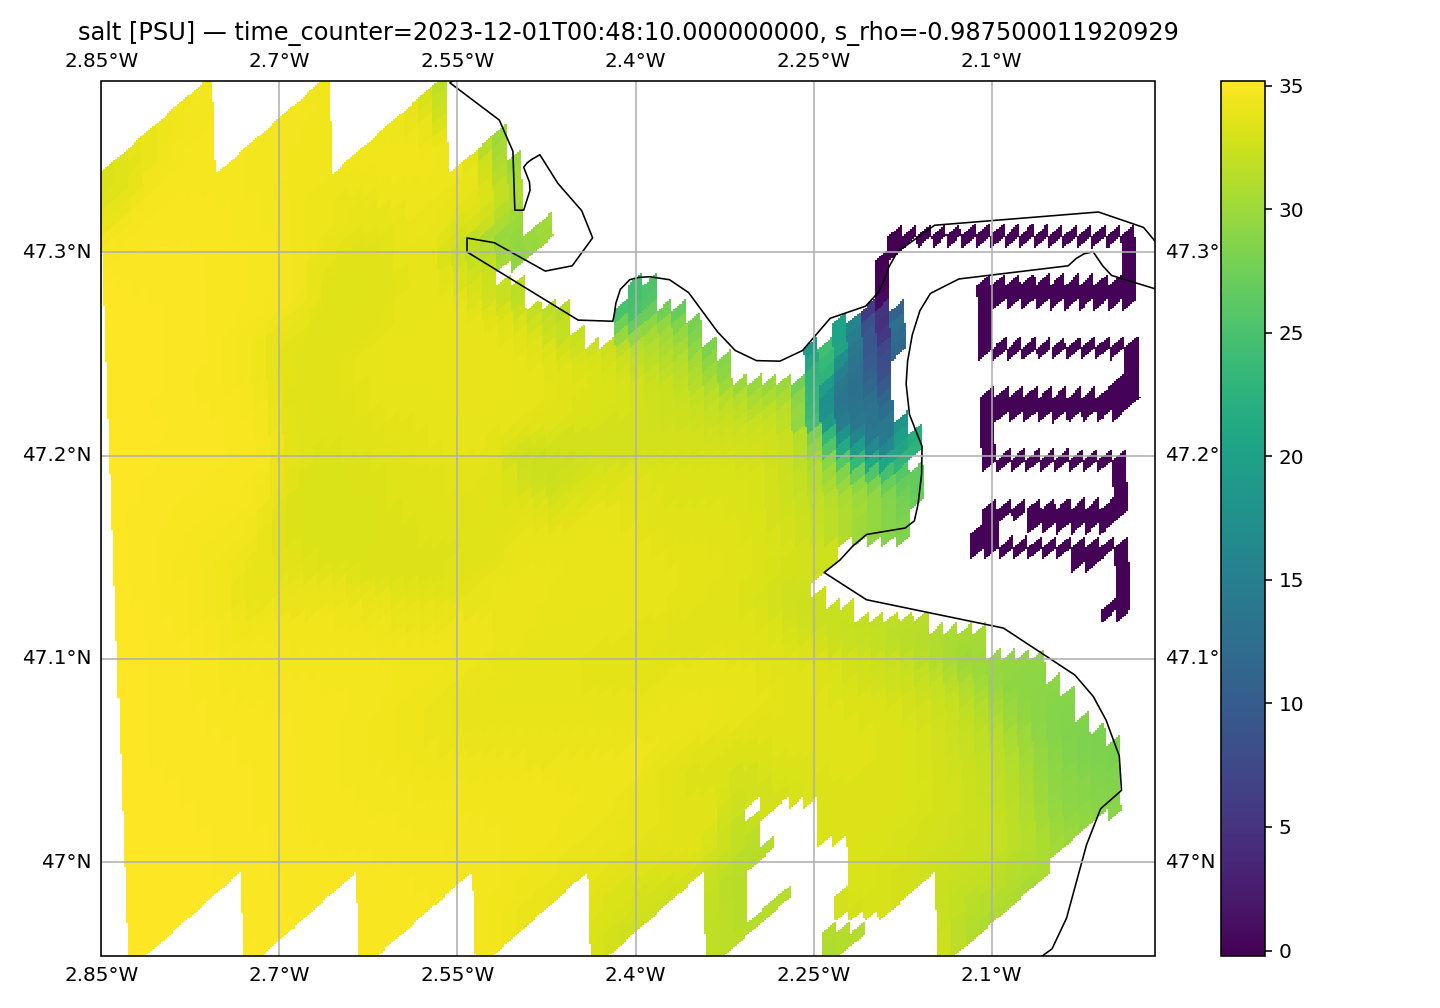

In [10]:
import panel as pn

pn.extension()

# Build widget options from the dataset
var_names = list(ds.data_vars)
dim_info = {}
for dim in ds.dims:
    if dim != "cell_ids":
        vals = ds[dim].values
        dim_info[dim] = vals

# Widgets
w_var = pn.widgets.Select(name="Variable", options=var_names, value=var_names[0])
dim_widgets = {}
for dim, vals in dim_info.items():
    labels = [str(v) for v in vals]
    w = pn.widgets.DiscreteSlider(name=dim, options=dict(zip(labels, range(len(vals)))), value=0)
    dim_widgets[dim] = w

w_cmap = pn.widgets.Select(
    name="Colormap",
    options=["viridis", "plasma", "inferno", "cividis", "RdYlBu_r", "coolwarm", "turbo"],
    value="viridis",
)
w_resolution = pn.widgets.IntSlider(name="Resolution", start=256, end=2048, step=256, value=512)


@pn.depends(w_var, *dim_widgets.values(), w_cmap, w_resolution)
def update_plot(var_name, *args):
    # Last two args are cmap and resolution
    cmap_val = args[-2]
    res_val = args[-1]
    dim_indices = args[:-2]

    da_v = ds[var_name]
    sel_dict = {}
    for (dim, vals), idx in zip(dim_info.items(), dim_indices):
        if dim in da_v.dims:
            sel_dict[dim] = vals[idx]

    values = da_v.sel(sel_dict).values.astype(np.float64)

    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(10, 7),
    )
    healpix_plot.plot(
        cell_ids,
        values,
        healpix_grid=healpix_grid,
        sampling_grid={"shape": res_val},
        projection="PlateCarree",
        ax=ax,
        cmap=cmap_val,
        colorbar=True,
    )
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
    ax.gridlines(draw_labels=True)

    sel_str = ", ".join(f"{k}={v}" for k, v in sel_dict.items())
    units = da_v.attrs.get("units", "")
    ax.set_title(f"{var_name} [{units}] — {sel_str}")
    plt.tight_layout()
    plt.close(fig)
    return fig


sidebar = pn.Column(
    "### Controls",
    w_var,
    *dim_widgets.values(),
    w_cmap,
    w_resolution,
)

dashboard = pn.Row(sidebar, update_plot)
dashboard.servable()